In [ ]:
from pathlib import Path
import json
import matplotlib as mpl
import matplotlib.pyplot as plt


EXPORT_ROOT = Path("paper_exports")
EXPORT_TABLES = EXPORT_ROOT / "tables"
EXPORT_FIGS = EXPORT_ROOT / "figures"
EXPORT_LOGS = EXPORT_ROOT / "logs"
for p in [EXPORT_ROOT, EXPORT_TABLES, EXPORT_FIGS, EXPORT_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 900,
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 10
})

print("Figures:", EXPORT_FIGS.resolve())
print("Tables:", EXPORT_TABLES.resolve())
print("Logs:", EXPORT_LOGS.resolve())


cr = Path("current_run.txt")

run_rel = cr.read_text().strip()
RUN_PATH = Path("experiments") / Path(run_rel)


CONFIG_PATH = RUN_PATH / "config.json"
if not CONFIG_PATH.exists():
    raise RuntimeError(f"config.json not found at {CONFIG_PATH}. Make sure the run is prepared.")

CONFIG = json.load(open(CONFIG_PATH))
RESULTS_PATH = RUN_PATH / "results"


Figures: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures
Tables: C:\Projects\multimodal_realestate_ml_public\paper_exports\tables
Logs: C:\Projects\multimodal_realestate_ml_public\paper_exports\logs


# ABLATION

#### common helper methods for ablation runs

In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

sar_df = sar_df.reindex(df_w.index).ffill()
sent_df = sent_df.reindex(df_w.index).ffill()
ir_series = ir_series.reindex(df_w.index).ffill()

selected_master_projects = [
    "Business Bay", "DAMAC HILLS 2", "DAMAC HILLS", "TOWN SQUARE", "DownTown Dubai",
    "Dubai Creek Harbour", "Dubai Marina", "Dubai South Residential District",
    "Dubai Sports City", "Al Furjan", "International City Phase 1", "Jumeirah Lakes Towers",
    "Jumeirah Village Circle", "Jumeirah Village Triangle", "Jumeriah Beach Residence  - JBR",
    "Mudon", "Palm Jumeirah", "Silicon Oasis", "The Greens"
]

region_targets = selected_master_projects + ["Global"]

sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value" or c.startswith("nsi_") or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

region_sat_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}

window = 12
horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]

modalities_order = ["P", "C", "S", "B", "I", "G"]
order_index = {m: i for i, m in enumerate(modalities_order)}

def canonicalize_tag(tag):
    letters = sorted(list(set(tag)), key=lambda x: order_index[x])
    return "".join(letters)

def build_flat_ir(tag, h, tgt):
    X = []
    y = []
    d = []
    sat_cols = region_sat_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag and sat_cols:
            parts.append(sar_df.iloc[i][sat_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if not parts:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

def eval_knn_tag_mae(tag_label, tick_every=50):
    tag = canonicalize_tag(tag_label)
    maes_all = []
    total_local = len(region_targets) * len(horizons)
    done_local = 0
    t0 = time.perf_counter()
    print(f"[Start] {tag_label} (canonical={tag})")
    for reg in region_targets:
        for h in horizons:
            Xf, yf, idx = build_flat_ir(tag, h, reg)
            if Xf.shape[0] == 0 or Xf.shape[1] == 0:
                done_local += 1
                continue
            folds = make_rolling_folds(idx)
            for tr, va, _, _, _ in folds:
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                maes_all.append(mean_absolute_error(yf[va], pred))
            done_local += 1
            if tick_every is not None and tick_every > 0:
                if done_local % tick_every == 0 or done_local == total_local:
                    pct = 100.0 * done_local / total_local
                    print(f"  [{tag_label}] {done_local}/{total_local} ({pct:.1f}%)")
    elapsed = time.perf_counter() - t0
    print(f"[Done ] {tag_label} in {elapsed:.1f}s")
    if len(maes_all) == 0:
        return np.nan
    return float(np.mean(maes_all))


### Sentiment Features Breakdowns -- PCA vs NSI 

In [ ]:
import random

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

print("Sentiment-feature KNN ablation started")

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth_finbert.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

sar_df = sar_df.reindex(df_w.index).ffill()
sent_df = sent_df.reindex(df_w.index).ffill()
ir_series = ir_series.reindex(df_w.index).ffill()

selected_master_projects = [
    "Business Bay",
    "DAMAC HILLS 2",
    "DAMAC HILLS",
    "TOWN SQUARE",
    "DownTown Dubai",
    "Dubai Creek Harbour",
    "Dubai Marina",
    "Dubai South Residential District",
    "Dubai Sports City",
    "Al Furjan",
    "International City Phase 1",
    "Jumeirah Lakes Towers",
    "Jumeirah Village Circle",
    "Jumeirah Village Triangle",
    "Jumeriah Beach Residence  - JBR",
    "Mudon",
    "Palm Jumeirah",
    "Silicon Oasis",
    "The Greens"
]

region_targets = selected_master_projects + ["Global"]
region_sat_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}

all_sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value"
    or c.startswith("nsi_")
    or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

nsi_cols = [c for c in all_sent_cols if c == "nsi_value" or c.startswith("nsi_")]
pca_cols = [c for c in all_sent_cols if c not in nsi_cols]

sent_configs = [
    ("no_sent", []),
    ("pca_only", pca_cols),
    ("nsi_only", nsi_cols),
    ("all_sent", all_sent_cols)
]

window = 12
all_horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]
long_horizons = [h for h in all_horizons if h >= 24]

tags = ["PCS", "PCSBIG"]

print("\n=== Data coverage ===")
def _span(idx):
    return idx.min().strftime("%Y-%m-%d"), idx.max().strftime("%Y-%m-%d"), len(idx)

for name, df in [("Prices", df_w), ("Counts", counts_df), ("Sentiment", sent_df), ("SAR", sar_df)]:
    smin, smax, n = _span(df.index)
    print(f"{name:>10}: {smin} → {smax}  n={n}")
print("Interest rate aligned:", not ir_series.isna().any())
print("======================\n")

def build_flat_ir(tag, h, tgt, sent_cols):
    X = []
    y = []
    d = []
    sat_cols = region_sat_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag and len(sent_cols) > 0:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag and sat_cols:
            parts.append(sar_df.iloc[i][sat_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if len(parts) == 0:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

rows = []

total = len(tags) * len(sent_configs) * len(region_targets) * len(long_horizons)
done = 0
tick_every = 20
t0 = time.perf_counter()

for tag in tags:
    print(f"[Tag] {tag}")
    for sent_name, sent_cols in sent_configs:
        print(f"  Sentiment config: {sent_name}")
        for reg in region_targets:
            for h in long_horizons:
                Xf, yf, idx = build_flat_ir(tag, h, reg, sent_cols)
                if Xf.shape[0] == 0 or yf.shape[0] == 0:
                    done += 1
                    if done % tick_every == 0 or done == total:
                        elapsed = time.perf_counter() - t0
                        print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")
                    continue

                folds = make_rolling_folds(idx)
                if len(folds) == 0:
                    done += 1
                    if done % tick_every == 0 or done == total:
                        elapsed = time.perf_counter() - t0
                        print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")
                    continue

                maes = []
                for fold_i, f in enumerate(folds):
                    tr = f[0]
                    va = f[1]
                    mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                    pred = mdl.predict(Xf[va])
                    mae = mean_absolute_error(yf[va], pred)
                    maes.append(mae)

                if len(maes) > 0:
                    m = float(np.mean(maes))
                    s = float(np.std(maes))
                    rows.append({
                        "tag": tag,
                        "region": reg,
                        "horizon": h,
                        "sent_config": sent_name,
                        "mae_mean": m,
                        "mae_std": s
                    })

                done += 1
                if done % tick_every == 0 or done == total:
                    elapsed = time.perf_counter() - t0
                    print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")

elapsed_total = time.perf_counter() - t0
print(f"\nSentiment-feature KNN ablation finished in {elapsed_total:.1f}s")

df_knn_sent_ablation = pd.DataFrame(rows)
print("Result rows:", len(df_knn_sent_ablation))
display(df_knn_sent_ablation.head())


Sentiment-feature KNN ablation started

=== Data coverage ===
    Prices: 2015-09-06 → 2025-09-28  n=526
    Counts: 2015-09-06 → 2025-09-28  n=526
 Sentiment: 2015-09-06 → 2025-09-28  n=526
       SAR: 2015-09-06 → 2025-09-28  n=526
Interest rate aligned: True

[Tag] PCS
  Sentiment config: no_sent
Progress 20/480  elapsed=5.2s
Progress 40/480  elapsed=8.4s
Progress 60/480  elapsed=11.2s
  Sentiment config: pca_only
Progress 80/480  elapsed=18.3s
Progress 100/480  elapsed=25.4s
Progress 120/480  elapsed=32.3s
  Sentiment config: nsi_only
Progress 140/480  elapsed=39.8s
Progress 160/480  elapsed=47.5s
Progress 180/480  elapsed=55.1s
  Sentiment config: all_sent
Progress 200/480  elapsed=62.7s
Progress 220/480  elapsed=70.1s
Progress 240/480  elapsed=77.6s
[Tag] PCSBIG
  Sentiment config: no_sent
Progress 260/480  elapsed=87.1s
Progress 280/480  elapsed=96.3s
Progress 300/480  elapsed=106.0s
  Sentiment config: pca_only
Progress 320/480  elapsed=121.4s
Progress 340/480  elapsed=137.3s
P

,tag,region,horizon,sent_config,mae_mean,mae_std
0,PCS,Business Bay,26,no_sent,5.045152,2.188719
1,PCS,Business Bay,30,no_sent,5.854088,2.807507
2,PCS,Business Bay,34,no_sent,5.723067,2.636543
3,PCS,DAMAC HILLS 2,26,no_sent,0.895414,0.743608
4,PCS,DAMAC HILLS 2,30,no_sent,0.846718,0.737825


,tag,region,sent_config,mae
0,PCS,Al Furjan,no_sent,5.048335
1,PCS,Business Bay,no_sent,5.540769
2,PCS,DAMAC HILLS,no_sent,3.538495
3,PCS,DAMAC HILLS 2,no_sent,0.875461
4,PCS,DownTown Dubai,no_sent,4.951616


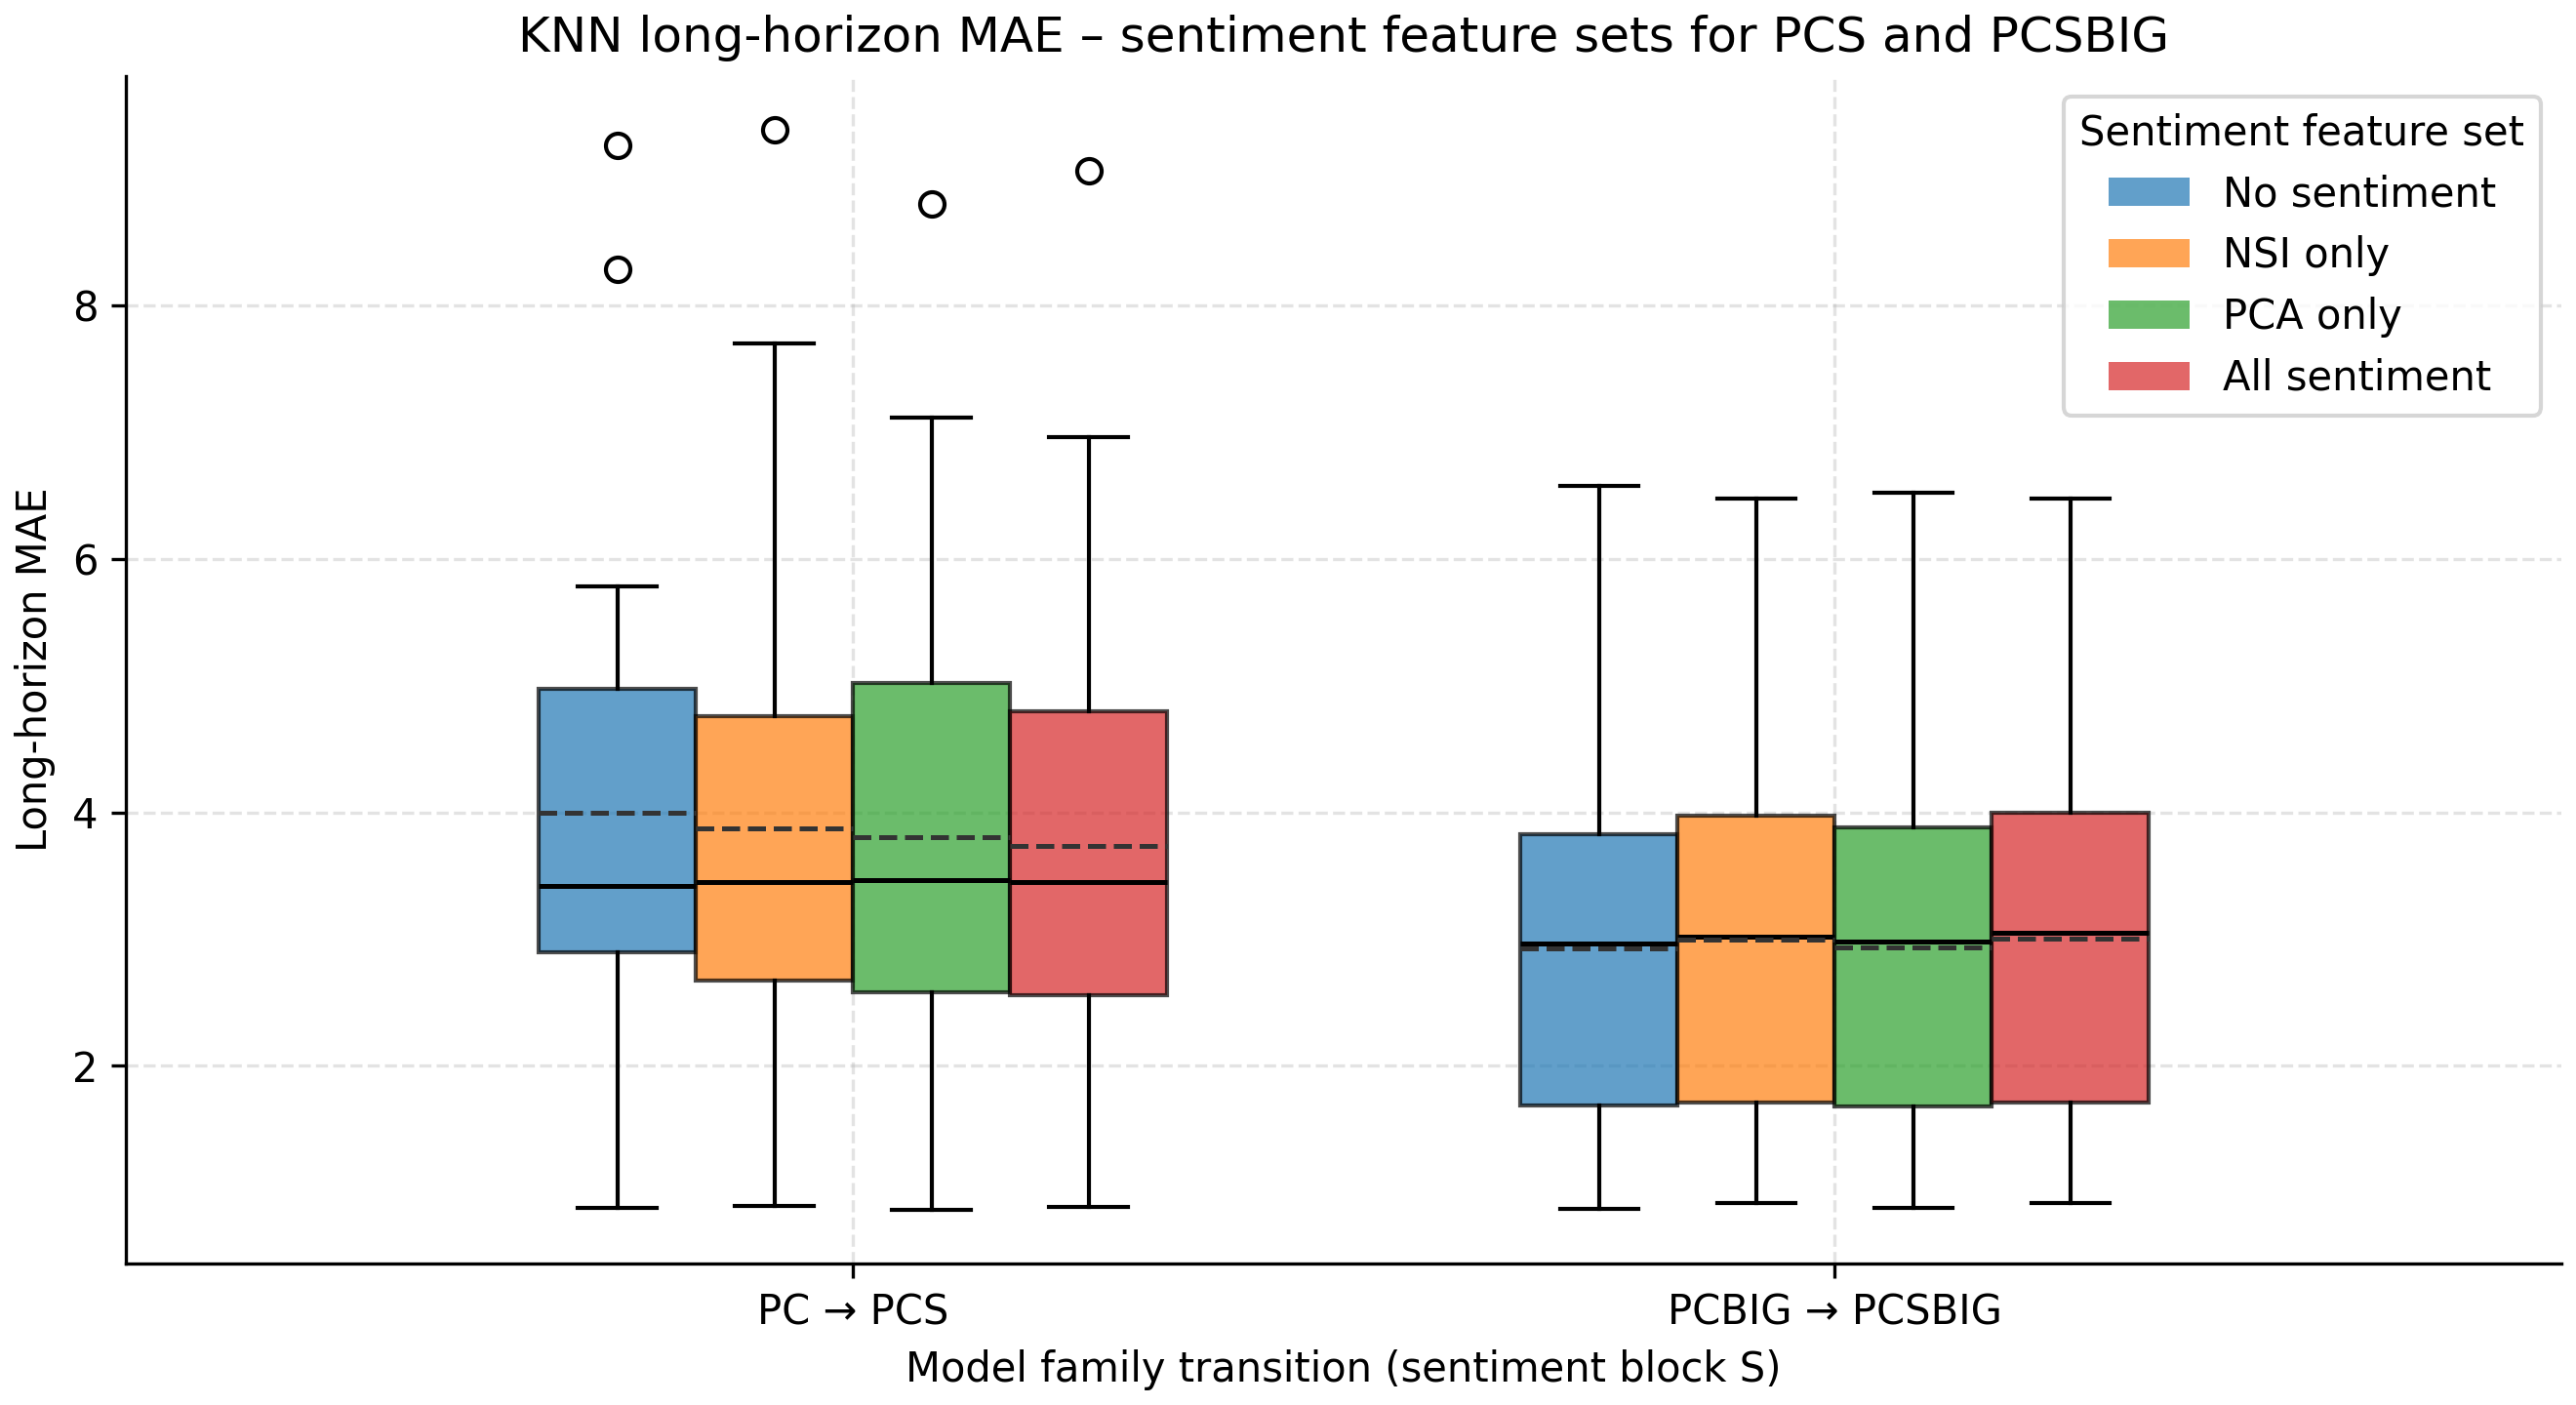

Saved sentiment feature-set comparison figure to: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures\knn_sentiment_feature_sets.png


In [ ]:
tags_interest = ["PCS", "PCSBIG"]
sent_configs_order = ["no_sent", "nsi_only", "pca_only", "all_sent"]
sent_labels = {
    "no_sent": "No sentiment",
    "nsi_only": "NSI only",
    "pca_only": "PCA only",
    "all_sent": "All sentiment"
}

df_sub = df_knn_sent_ablation[df_knn_sent_ablation["tag"].isin(tags_interest)].copy()

def build_long_by_region(df):
    records = []
    for tag in tags_interest:
        for sent_name in sent_configs_order:
            df_ts = df[(df["tag"] == tag) & (df["sent_config"] == sent_name)]
            if len(df_ts) == 0:
                continue
            for region, df_r in df_ts.groupby("region"):
                mval = float(df_r["mae_mean"].mean())
                records.append({
                    "tag": tag,
                    "region": region,
                    "sent_config": sent_name,
                    "mae": mval
                })
    return pd.DataFrame(records)

df_long = build_long_by_region(df_sub)
display(df_long.head())

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(tags_interest))
width = 0.16

data_no = []
data_nsi = []
data_pca = []
data_all = []

for tag in tags_interest:
    df_tag = df_long[df_long["tag"] == tag]
    data_no.append(df_tag[df_tag["sent_config"] == "no_sent"]["mae"].values)
    data_nsi.append(df_tag[df_tag["sent_config"] == "nsi_only"]["mae"].values)
    data_pca.append(df_tag[df_tag["sent_config"] == "pca_only"]["mae"].values)
    data_all.append(df_tag[df_tag["sent_config"] == "all_sent"]["mae"].values)

pos_no = x - 1.5 * width
pos_nsi = x - 0.5 * width
pos_pca = x + 0.5 * width
pos_all = x + 1.5 * width

colors = plt.colormaps["tab10"].colors

bp_no = ax.boxplot(
    data_no,
    positions=pos_no,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

bp_nsi = ax.boxplot(
    data_nsi,
    positions=pos_nsi,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

bp_pca = ax.boxplot(
    data_pca,
    positions=pos_pca,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

bp_all = ax.boxplot(
    data_all,
    positions=pos_all,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

for patch in bp_no["boxes"]:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.7)

for patch in bp_nsi["boxes"]:
    patch.set_facecolor(colors[1])
    patch.set_alpha(0.7)

for patch in bp_pca["boxes"]:
    patch.set_facecolor(colors[2])
    patch.set_alpha(0.7)

for patch in bp_all["boxes"]:
    patch.set_facecolor(colors[3])
    patch.set_alpha(0.7)

ax.set_xticks(x)
ax.set_xticklabels(
    ["PC → PCS", "PCBIG → PCSBIG"],
    rotation=0
)

ax.set_xlabel("Model family transition (sentiment block S)")
ax.set_ylabel("Long-horizon MAE")
ax.set_title("KNN long-horizon MAE – sentiment feature sets for PCS and PCSBIG")

handles = [
    mpl.patches.Patch(facecolor=colors[0], alpha=0.7, label=sent_labels["no_sent"]),
    mpl.patches.Patch(facecolor=colors[1], alpha=0.7, label=sent_labels["nsi_only"]),
    mpl.patches.Patch(facecolor=colors[2], alpha=0.7, label=sent_labels["pca_only"]),
    mpl.patches.Patch(facecolor=colors[3], alpha=0.7, label=sent_labels["all_sent"])
]
ax.legend(handles=handles, title="Sentiment feature set", loc="upper right")

plt.tight_layout()

outfile = EXPORT_FIGS / "knn_sentiment_feature_sets.png"
fig.savefig(outfile, bbox_inches="tight")
plt.show()
fig.savefig(outfile, dpi=900, format="png", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

print("Saved sentiment feature-set comparison figure to:", outfile.resolve())


In [ ]:
from scipy import stats

sent_configs_order = ["no_sent", "nsi_only", "pca_only", "all_sent"]
pcs_df = df_knn_sent_ablation[df_knn_sent_ablation["tag"] == "PCS"].copy()

records = []
for sent_name in sent_configs_order:
    df_s = pcs_df[pcs_df["sent_config"] == sent_name]
    if len(df_s) == 0:
        continue
    for region, df_r in df_s.groupby("region"):
        mval = float(df_r["mae_mean"].mean())
        records.append({
            "region": region,
            "sent_config": sent_name,
            "mae": mval
        })

df_long_pcs = pd.DataFrame(records)
if df_long_pcs.empty:
    raise RuntimeError("No PCS rows found in df_knn_sent_ablation for the requested sentiment configs.")

pivot = df_long_pcs.pivot(index="region", columns="sent_config", values="mae")
pivot = pivot.reindex(columns=sent_configs_order)

def one_sided_paired_t(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    xv = x[mask]
    yv = y[mask]
    if xv.size == 0:
        return np.nan, np.nan, 0
    t_res = stats.ttest_rel(xv, yv)
    diff_mean = float(np.mean(xv - yv))
    p_two = float(t_res.pvalue)
    if diff_mean < 0:
        p_one = p_two / 2.0
    else:
        p_one = 1.0 - p_two / 2.0
    return diff_mean, p_one, xv.size

baseline = pivot["no_sent"].to_numpy()

rows = []
for cfg in ["nsi_only", "pca_only", "all_sent"]:
    if cfg not in pivot.columns:
        continue
    alt = pivot[cfg].to_numpy()
    diff_mean, p_one, n_regions = one_sided_paired_t(alt, baseline)
    rows.append({
        "comparison": cfg,
        "n_regions": n_regions,
        "mean_diff_alt_minus_no_sent": diff_mean,
        "p_one_sided_alt_lower": p_one
    })

df_pcs_tests = pd.DataFrame(rows)
print("PCS paired t-tests (H1: alt MAE < no_sent MAE):")
display(df_pcs_tests)


PCS paired t-tests (H1: alt MAE < no_sent MAE):


,comparison,n_regions,mean_diff_alt_minus_no_sent,p_one_sided_alt_lower
0,nsi_only,20,-0.124437,0.034784
1,pca_only,20,-0.192884,0.006933
2,all_sent,20,-0.264037,0.004717
